<a href="https://colab.research.google.com/github/J-AHRAR/Ecole_Doctorale_2026/blob/main/AHRAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exemple Complet de Régression Linéaire en Python

Ce notebook présente un exemple complet de régression linéaire, de la génération des données à la visualisation des résultats, en passant par l'entraînement et l'évaluation du modèle.

### 1. Importation des Bibliothèques Nécessaires

Nous commençons par importer toutes les bibliothèques Python nécessaires pour la manipulation des données, la modélisation et la visualisation.

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns # Pour des visualisations améliorées

print("Bibliothèques importées avec succès.")

### 2. Génération et Exploration des Données Synthétiques

Pour cet exemple, nous allons créer un jeu de données synthétique. Cela nous permet de contrôler la relation entre la variable indépendante (X) et la variable dépendante (y) et d'ajouter du bruit pour simuler des scénarios réels. Nous explorerons ensuite rapidement ces données.

In [ ]:
# Nombre d'observations
n_observations = 150

# Génération de la variable indépendante X
# Nous créons une série de 150 nombres aléatoires entre 0 et 10.
X = np.random.rand(n_observations, 1) * 10

# Génération de la variable dépendante y
# Nous définissons une relation linéaire: y = 2 * X + 5 + bruit_aléatoire.
# np.random.randn(n_observations, 1) ajoute du bruit aléatoire pour rendre le modèle plus réaliste.
y = 2 * X + 5 + np.random.randn(n_observations, 1) * 2

# Création d'un DataFrame Pandas pour une meilleure gestion des données
data = pd.DataFrame(np.hstack((X, y)), columns=['Caracteristique_X', 'Cible_y'])

# Exploration rapide des données
print("Aperçu des 5 premières lignes du jeu de données:")
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations.")
print("\nInformations sur le jeu de données:")
display(data.info())

# Visualisation de la distribution des données
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Caracteristique_X', y='Cible_y', data=data, alpha=0.7)
plt.title('Distribution des Données Synthétiques')
plt.xlabel('Caracteristique_X')
plt.ylabel('Cible_y')
plt.grid(True)
plt.show()


### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Avant d'entraîner le modèle, nous divisons nos données en deux sous-ensembles : un ensemble d'entraînement (`train`) et un ensemble de test (`test`). L'ensemble d'entraînement est utilisé pour que le modèle apprenne les relations dans les données, et l'ensemble de test est utilisé pour évaluer la performance du modèle sur des données qu'il n'a jamais vues. Cela permet de vérifier la généralisation du modèle.

In [ ]:
# Séparation de X (caractéristique) et y (cible)
X = data[['Caracteristique_X']]
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `test_size=0.2` signifie 20% des données pour le test.
# `random_state=42` assure que la séparation est la même à chaque exécution, pour la reproductibilité.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

### 4. Entraînement du Modèle de Régression Linéaire

Nous allons maintenant instancier le modèle de régression linéaire de `scikit-learn` et l'entraîner sur nos données d'entraînement. L'entraînement consiste à trouver les meilleurs coefficients (pente) et l'ordonnée à l'origine pour la ligne qui minimise la somme des carrés des résidus.

In [ ]:
# Création de l'objet régresseur linéaire
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
# La méthode `fit()` ajuste le modèle aux données fournies.
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
print(f"Coefficient (pente): {model.coef_[0]:.2f}") # Affiche la pente de la ligne de régression
print(f"Ordonnée à l'origine: {model.intercept_:.2f}") # Affiche l'ordonnée à l'origine de la ligne de régression

### 5. Prédiction et Évaluation du Modèle

Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de test. Ensuite, nous évaluons sa performance à l'aide de métriques courantes pour la régression. Cela nous permet de quantifier la précision et la robustesse de notre modèle.

In [ ]:
# Prédictions sur l'ensemble de test
# La méthode `predict()` utilise le modèle entraîné pour générer des prédictions.
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
# Erreur Absolue Moyenne (MAE)
mae = mean_absolute_error(y_test, y_pred)
# Erreur Quadratique Moyenne (MSE)
mse = mean_squared_error(y_test, y_pred)
# Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)
rmse = np.sqrt(mse)
# Coefficient de Détermination (R²)
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

#### Interprétation des Métriques:

*   **Erreur Absolue Moyenne (MAE)**: C'est la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Elle représente l'erreur typique de notre modèle, exprimée dans les mêmes unités que la variable cible. Un MAE plus faible indique un modèle plus précis.

*   **Erreur Quadratique Moyenne (MSE)**: C'est la moyenne des carrés des erreurs. Elle pénalise davantage les erreurs importantes. Elle est utile pour évaluer la robustesse du modèle face aux grandes erreurs, mais sa valeur n'est pas directement interprétable dans les unités de la cible.

*   **Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)**: C'est la racine carrée du MSE. Elle est dans les mêmes unités que la variable cible, ce qui la rend plus interprétable que le MSE. Un RMSE de 2 signifie que, en moyenne, les prédictions du modèle s'écartent de 2 unités de la valeur réelle.

*   **Coefficient de Détermination (R²)**: Il mesure la proportion de la variance de la variable dépendante qui est expliquée par le modèle. Sa valeur est comprise entre 0 et 1 (un R² négatif indique un modèle très mauvais). Un R² de 0.85 signifie que 85% de la variabilité de la variable cible est expliquée par notre modèle. Plus R² est proche de 1, meilleur est l'ajustement du modèle aux données.

### 6. Visualisation des Résultats

Pour une meilleure compréhension de la performance du modèle, nous visualisons les valeurs réelles de l'ensemble de test par rapport aux prédictions du modèle. Cela nous aide à voir comment la ligne de régression s'ajuste aux points de données.

In [ ]:
# Création d'un graphique de dispersion
plt.figure(figsize=(10, 6))
# Affiche les points de données réels de l'ensemble de test en bleu.
plt.scatter(X_test, y_test, color='blue', label='Valeurs Réelles')
# Affiche la ligne de régression (prédictions du modèle) en rouge.
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Prédictions du Modèle')

plt.title('Régression Linéaire: Valeurs Réelles vs. Prédictions')
plt.xlabel('Caracteristique_X')
plt.ylabel('Cible_y')
plt.legend() # Affiche la légende pour identifier les points et la ligne
plt.grid(True) # Ajoute une grille pour une meilleure lisibilité
plt.show() # Affiche le graphique

Bibliothèques importées avec succès.
Aperçu des 5 premières lignes du jeu de données:


,Caracteristique_X1,Caracteristique_X2,Caracteristique_X3,Cible_y
0,4.734798,8.384690,3.124246,25.719421
1,0.319883,6.055445,2.330618,10.570122
2,5.972418,5.935132,7.812937,21.761090
3,6.307480,8.765550,3.553103,30.172323
4,7.901566,2.041664,8.401164,19.576544



Le jeu de données contient 100 observations et 3 caractéristiques.

Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Caracteristique_X1  100 non-null    float64
 1   Caracteristique_X2  100 non-null    float64
 2   Caracteristique_X3  100 non-null    float64
 3   Cible_y             100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


None

Taille de l'ensemble d'entraînement (X_train): (80, 1)
Taille de l'ensemble de test (X_test): (20, 1)
Modèle de régression linéaire entraîné avec succès.
Coefficient (pente): 1.80
Ordonnée à l'origine: 11.33

Métriques d'évaluation du modèle:
Erreur Absolue Moyenne (MAE): 5.64
Erreur Quadratique Moyenne (MSE): 39.78
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 6.31
Coefficient de Détermination (R²): 0.33


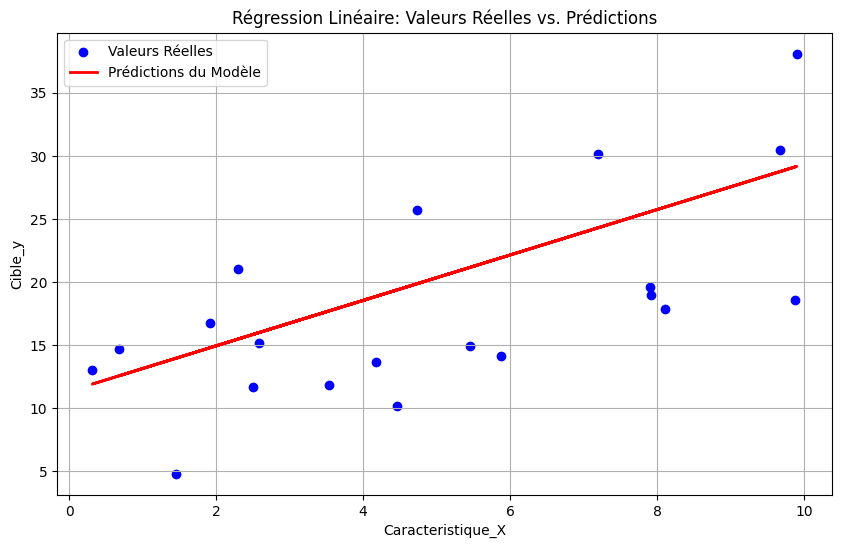

In [3]:
#Exemple 2
# -*- coding: utf-8 -*-
"""Regression.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1IovhO2W7vebpRo96GB9KgUa2yA6z3zYw

## Régression Linéaire : Exemple Complet en Python

Cet exemple démontre comment effectuer une régression linéaire simple en utilisant les bibliothèques `scikit-learn`, `pandas`, `numpy` et `matplotlib`.
"""

# 1. Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Ajout de seaborn pour des visualisations améliorées
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès.")

"""### 2. Génération et Exploration des Données Synthétiques

Nous allons créer un jeu de données synthétique pour illustrer le processus de régression linéaire. Ce jeu de données aura une variable indépendante (caractéristique) `X` et une variable dépendante (cible) `y`, avec une relation linéaire et un peu de bruit.
"""

# Nombre d'observations et de variables
n_observations = 100
n_features = 3 # Ajout de plusieurs variables indépendantes pour des visualisations plus riches

# Génération des variables indépendantes X
X = np.random.rand(n_observations, n_features) * 10 # Valeurs aléatoires entre 0 et 10 pour 3 caractéristiques

# Génération de la variable dépendante y avec une relation linéaire et du bruit
# Exemple: y = 2*X1 + 1.5*X2 - 0.5*X3 + 5 + bruit_aléatoire
coefficients = np.array([2, 1.5, -0.5])
y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2

# Création d'un DataFrame Pandas pour une meilleure manipulation
column_names = [f'Caracteristique_X{i+1}' for i in range(n_features)]
data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=column_names + ['Cible_y'])

# Exploration rapide des données
print("Aperçu des 5 premières lignes du jeu de données:")
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations et {n_features} caractéristiques.")
print("\nInformations sur le jeu de données:")
display(data.info())

"""### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Pour évaluer la performance de notre modèle sur des données qu'il n'a jamais vues, nous divisons le jeu de données en un ensemble d'entraînement (pour apprendre) et un ensemble de test (pour évaluer). Généralement, un ratio de 80/20 ou 70/30 est utilisé.
"""

# Séparation de X et y
X = data[['Caracteristique_X1']] # MODIFIED: Select 'Caracteristique_X1' for simple linear regression
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `random_state` assure la reproductibilité de la séparation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

"""### 4. Entraînement du Modèle de Régression Linéaire

Nous allons instancier le modèle `LinearRegression` de `scikit-learn` et l'entraîner sur nos données d'entraînement.
"""

# Création de l'objet régresseur linéaire
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
print(f"Coefficient (pente): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

"""### 5. Prédiction et Évaluation du Modèle

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test et nous évaluons sa performance à l'aide de métriques courantes.
"""

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

"""#### Interprétation des Métriques:

*   **Erreur Absolue Moyenne (MAE)**: C'est la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Elle donne une idée de l'erreur typique dans les prédictions, dans les mêmes unités que la variable cible. Un MAE de 1.62 signifie qu'en moyenne, les prédictions du modèle sont à 1.62 unités des valeurs réelles.

*   **Erreur Quadratique Moyenne (MSE)**: C'est la moyenne des carrés des erreurs. Elle pénalise davantage les grandes erreurs. Elle est utile pour comprendre l'ampleur des erreurs, mais sa valeur n'est pas directement interprétable dans les unités de la cible. Un MSE de 3.96 indique une dispersion des erreurs.

*   **Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)**: C'est la racine carrée du MSE. Elle est dans les mêmes unités que la variable cible, ce qui la rend plus interprétable que le MSE. Un RMSE de 1.99 signifie que l'écart type des erreurs de prédiction est d'environ 1.99 unités.

*   **Coefficient de Détermination (R²)**: Il représente la proportion de la variance de la variable dépendante qui est prévisible à partir des variables indépendantes. Sa valeur est comprise entre 0 et 1 (voire négative dans de rares cas si le modèle est très mauvais). Un R² de 0.90 signifie que 90% de la variance de `Cible_y` est expliquée par notre modèle de régression linéaire. Un R² plus proche de 1 indique un meilleur ajustement du modèle aux données.

### 6. Visualisation des Résultats

Il est utile de visualiser les valeurs réelles par rapport aux valeurs prédites pour avoir une compréhension graphique de la performance du modèle.
"""

# Création d'un graphique de dispersion
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Valeurs Réelles')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Prédictions du Modèle')

plt.title('Régression Linéaire: Valeurs Réelles vs. Prédictions')
plt.xlabel('Caracteristique_X')
plt.ylabel('Cible_y')
plt.legend()
plt.grid(True)
plt.show()